# Soybean Yield Analysis — BioCro, DASST (CSM-CROPGRO), WOFOST
# Maps (Observed vs Modeled) and Bar Charts (District 90 & 60)

In [5]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Set working directory to the project root (parent of Figures/)
# This is idempotent — safe to re-run without moving up extra levels
if os.path.basename(os.getcwd()) == "Figures":
    os.chdir("..")
print("Working directory:", os.getcwd())



Working directory: c:\BioCro_DSSAT_WOFOST_Egorov_etal_paper-main


In [6]:
# ---------------------------------------------------------------------------
# Data paths (all relative to data/ subdirectory)
# ---------------------------------------------------------------------------
DATA_ROOT = "./data"

BIOCRO_GEOJSON_PATH  = f'{DATA_ROOT}/USDA_crop_model.geojson'
BOUNDARY_GEOJSON_PATH = f'{DATA_ROOT}/BOUNDARY.geojson'
US_STATES_GEOJSON_PATH = f'{DATA_ROOT}/us_states_for_map.geojson'
COUNTIES_USA_GEOJSON_PATH = f'{DATA_ROOT}/counties_usa_for_map.geojson'
AG_DIS_N_GEOJSON_PATH = f'{DATA_ROOT}/ag_dis_n.geojson'

USDA_DISTRICT_90_CSV = f'{DATA_ROOT}/USDA_soyben_District_90.csv'
USDA_DISTRICT_60_CSV = f'{DATA_ROOT}/USDA_soyben_District_60.csv'

BIOCRO_D90_CSV = f'{DATA_ROOT}/district_90_biocro.csv'
CSM_D90_CSV    = f'{DATA_ROOT}/district_90_csm.csv'
WOFOST_D90_CSV = f'{DATA_ROOT}/district_90_W.csv'

BIOCRO_D60_CSV = f'{DATA_ROOT}/district_60_biocro.csv'
CSM_D60_CSV    = f'{DATA_ROOT}/district_60_csm.csv'
WOFOST_D60_CSV = f'{DATA_ROOT}/district_60_W.csv'

# ---------------------------------------------------------------------------
# Plot styling
# ---------------------------------------------------------------------------
CMAP_YIELD       = 'YlGn'
LINE_W           = 0.5
LINE_W_USA       = 2.5
LINE_W_USA_COUNTIES = 0.5
COLOR_USA        = 'black'
COLOR_COUNTIES   = 'gray'
COLOR_AOI        = 'gray'
FACECOLOR        = 'lightgray'

ZOOM_PADDING     = 0.20
ZOOM_PADDING_MINI = 10
BORDERPAD_MINI   = -0.36

# Fixed modeled yield range (shared across all three models)
VMIN_MODELED = 2.9
VMAX_MODELED = 4.2

# Bar chart colours
COLOR_USDA   = 'gray'
COLOR_BIOCRO = 'blue'
COLOR_DSSAT  = 'magenta'
COLOR_WOFOST = 'lime'

In [7]:
def set_zoom(ax, gdf, zoom_factor):
    """Adjust x/y limits of ax based on bounding box of gdf with padding."""
    x_min, y_min, x_max, y_max = gdf.total_bounds
    x_pad = (x_max - x_min) * zoom_factor
    y_pad = (y_max - y_min) * zoom_factor
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)


def plot_yield_map(gdf, model_col, model_label,
                   observed_col='USDA Crop yield',
                   vmin_obs=None, vmax_obs=None,
                   vmin_mod=VMIN_MODELED, vmax_mod=VMAX_MODELED):
    """
    Plot a 2-panel figure: Observed | Modeled with inset mini-maps.
    
    Parameters
    ----------
    gdf          : GeoDataFrame with yield data.
    model_col    : column name for modeled yield.
    model_label  : human-readable model name (e.g. 'BioCro').
    observed_col : column for observed (USDA) yield.
    vmin_obs/vmax_obs : colour-range for observed map (auto from data if None).
    vmin_mod/vmax_mod : colour-range for modeled map.
    """
    if vmin_obs is None:
        vmin_obs = gdf[observed_col].min()
    if vmax_obs is None:
        vmax_obs = gdf[observed_col].max()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    # Inset bounds (computed once from the data extent)
    ne = gdf.total_bounds
    xm, ym, xM, yM = ne
    xp = (xM - xm) * ZOOM_PADDING_MINI
    yp = (yM - ym) * ZOOM_PADDING_MINI

    def _draw_inset(parent_ax):
        ins = inset_axes(parent_ax, width=1.5, height=1.5, loc='upper right',
                         borderpad=0, bbox_to_anchor=(1.00, 1.033),
                         bbox_transform=parent_ax.transAxes)
        district_60.to_crs(epsg=4326).plot(ax=ins, color='black',
                                           edgecolor='black', alpha=0.5)
        ins.set_xlim(xm - xp, xM + xp)
        ins.set_ylim(ym - yp, yM + yp)
        us_states_4326.plot(ax=ins, color='lightgray', edgecolor='black', alpha=1.0)
        gdf.plot(ax=ins, color='lightgray', edgecolor='red', alpha=1.0)
        ins.set_xticks([]); ins.set_yticks([]); ins.set_title("")

    def _base_layers(ax):
        counties_usa.plot(ax=ax, facecolor='none', edgecolor=COLOR_USA,
                          linewidth=LINE_W_USA_COUNTIES, zorder=5)
        us_states.plot(ax=ax, facecolor='none', edgecolor=COLOR_USA,
                       linewidth=LINE_W_USA, zorder=5)
        temp_shp.plot(ax=ax, facecolor='none', edgecolor='black',
                      linewidth=2.0, zorder=15)

    # --- AX1: Observed ---
    _base_layers(ax1)
    gdf.plot(ax=ax1, column=observed_col, cmap=CMAP_YIELD, legend=True,
             legend_kwds={'label': "Mean Grain Yield (Observed)", 'orientation': "horizontal"},
             edgecolor=COLOR_AOI, linewidth=LINE_W,
             vmin=vmin_obs, vmax=vmax_obs, zorder=3)
    ax1.set_title("Observed Yield (USDA) 2002-2006", fontsize=14)
    ax1.set_facecolor(FACECOLOR); ax1.set_xlabel("Longitude"); ax1.set_ylabel("Latitude")
    set_zoom(ax1, gdf, ZOOM_PADDING)
    _draw_inset(ax1)

    # --- AX2: Modeled ---
    _base_layers(ax2)
    gdf.plot(ax=ax2, column=model_col, cmap=CMAP_YIELD, legend=True,
             legend_kwds={'label': f"Modeled Yield ({model_label}, tons/ha)", 'orientation': "horizontal"},
             edgecolor=COLOR_AOI, linewidth=LINE_W,
             vmin=vmin_mod, vmax=vmax_mod, zorder=3)
    ax2.set_title(f"Modeled Yield ({model_label}) 2002-2006", fontsize=14)
    ax2.set_facecolor(FACECOLOR); ax2.set_xlabel("Longitude"); ax2.set_ylabel("")
    set_zoom(ax2, gdf, ZOOM_PADDING)
    _draw_inset(ax2)

    plt.tight_layout()
    plt.show()


def plot_bar_chart(usda_csv, biocro_csv, csm_csv, wofost_csv, district_label):
    """
    Plot a grouped bar chart comparing USDA, BioCro, CSM-CROPGRO, and WOFOST
    soybean yields for a given AG district.
    """
    data = pd.read_csv(usda_csv)
    Mean_Yield     = data['Mean Yield (2002-2006) in Tons/Ha'].tolist()
    Mean_Yield_std = data['Std Dev Yield (2002-2006) in Tons/Ha'].tolist()

    biocro_df = pd.read_csv(biocro_csv)
    biocro_Yield     = biocro_df['mean_grain_yield_B'].tolist()
    biocro_Yield_std = biocro_df['STD_2002_2006_B'].tolist()

    csm_df = pd.read_csv(csm_csv)
    csm_Yield     = csm_df['mean_grain_yield_D'].tolist()
    csm_Yield_std = csm_df['STD_2002_2006_D'].tolist()

    wofost_df = pd.read_csv(wofost_csv)
    wofost_Yield     = wofost_df['mean_grain_yield_W'].tolist()
    wofost_Yield_std = wofost_df['STD_2002_2006_W'].tolist()

    # Shortened county names
    data["name_short"] = data["County"].str[:1].str.upper() + data["County"].str[1:2].str.lower()
    county_list = data["name_short"].tolist()

    df = pd.DataFrame({
        'county': county_list,
        'USDA':   Mean_Yield,     'USDA_std':   Mean_Yield_std,
        'BioCro': biocro_Yield,   'BioCro_std': biocro_Yield_std,
        'CSM':    csm_Yield,      'CSM_std':    csm_Yield_std,
        'WOFOST': wofost_Yield,   'WOFOST_std': wofost_Yield_std,
    })

    x = np.arange(len(df))
    width = 0.15

    fig, ax = plt.subplots(figsize=(15, 8))
    ax.bar(x - 3*width/2, df['USDA'],   width, yerr=df['USDA_std'],
           label='USDA',            capsize=5, color=COLOR_USDA,   edgecolor='black')
    ax.bar(x - width/2,   df['BioCro'], width, yerr=df['BioCro_std'],
           label='Soybean-BioCro',  capsize=5, color=COLOR_BIOCRO, edgecolor='black')
    ax.bar(x + width/2,   df['CSM'],    width, yerr=df['CSM_std'],
           label='CSM CROPGRO',     capsize=5, color=COLOR_DSSAT,  edgecolor='black')
    ax.bar(x + 3*width/2, df['WOFOST'], width, yerr=df['WOFOST_std'],
           label='WOFOST',          capsize=5, color=COLOR_WOFOST, edgecolor='black')

    ax.set_ylabel('Soybean Yields (T/Ha)')
    ax.set_xticks(x)
    ax.set_xticklabels(df['county'], rotation=0, ha='right')
    ax.set_title(f'AG {district_label}')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

    return df

In [8]:
# ---------------------------------------------------------------------------
# Load GeoJSON files
# ---------------------------------------------------------------------------
temp_shp     = gpd.read_file(BOUNDARY_GEOJSON_PATH)
us_states    = gpd.read_file(US_STATES_GEOJSON_PATH)
counties_usa = gpd.read_file(COUNTIES_USA_GEOJSON_PATH)
district_60  = gpd.read_file(AG_DIS_N_GEOJSON_PATH)
district_60  = district_60.set_crs(epsg=4326)

# Reproject to Web Mercator for contextily compatibility
district_60 = district_60.to_crs(epsg=3857)
us_states   = us_states.to_crs(epsg=3857)

# Keep a 4326 copy for inset maps
us_states_4326 = us_states.to_crs(epsg=4326)

# ---------------------------------------------------------------------------
# Load BioCro GeoJSON (main soybean yield data)
# ---------------------------------------------------------------------------
print("Loading USDA crop model GeoJSON data...")
grain_mean_BioCro_districts = gpd.read_file(BIOCRO_GEOJSON_PATH)

if grain_mean_BioCro_districts.crs is None:
    grain_mean_BioCro_districts = grain_mean_BioCro_districts.set_crs(epsg=4326)

print(f"Loaded {len(grain_mean_BioCro_districts)} features")
print(f"Columns: {grain_mean_BioCro_districts.columns.tolist()}")

Loading USDA crop model GeoJSON data...
Loaded 28 features
Columns: ['CLASSFP', 'NAME', 'NAMELSAD', 'join_name', 'county', 'USDA Crop yield', 'USDA Crop yield-std', 'biocro Crop yield', 'biocro Crop yield std', 'DASST_soyben Crop yield', 'DASST_soyben Crop yield std', 'wofrst Crop yield', 'wofrst Crop yield std', 'NAME_FULL', 'county_label', 'geometry']


C:\Users\yaron\AppData\Local\Temp\ipykernel_1536\4110487631.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


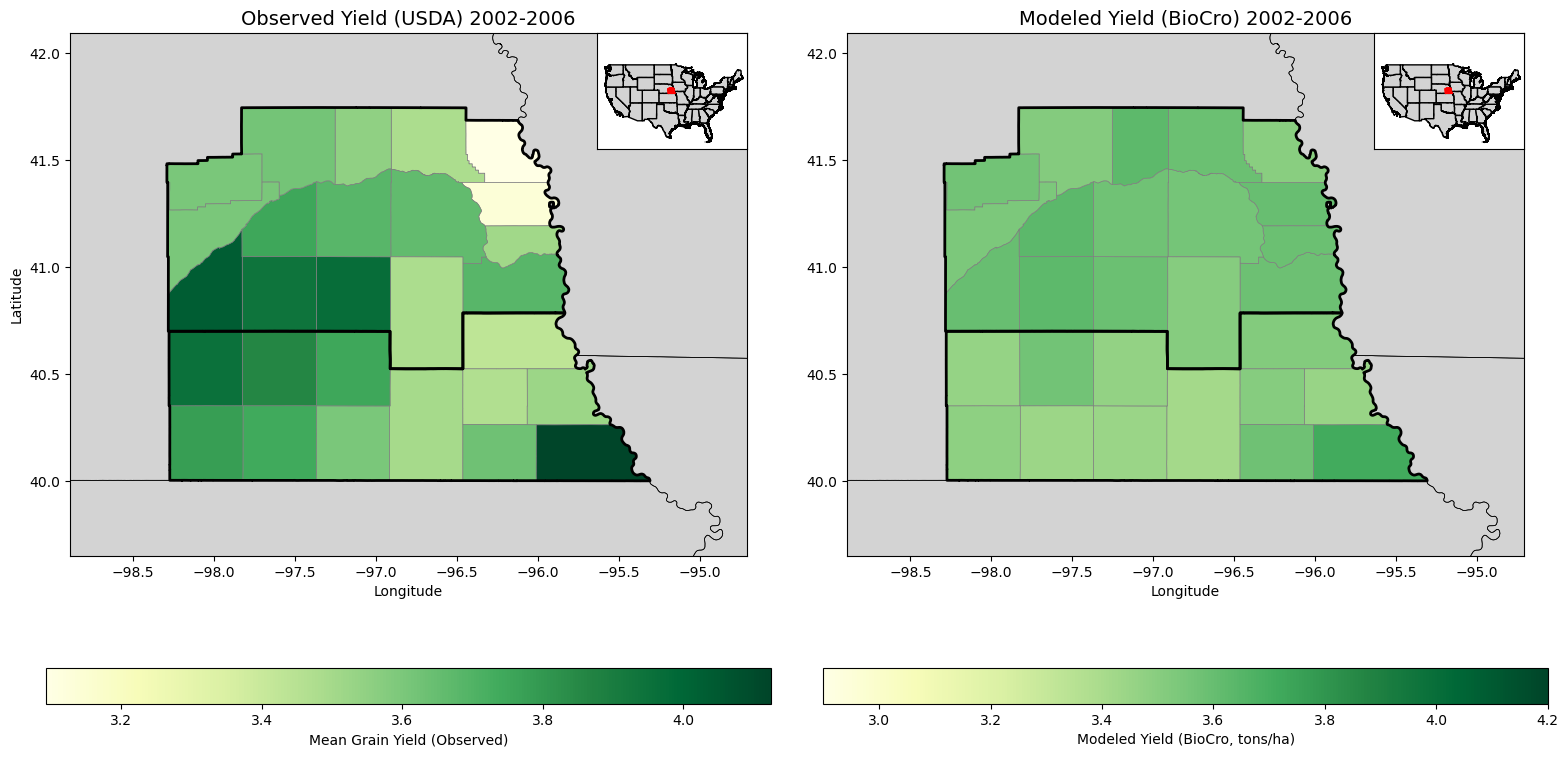

✓ BioCro maps generated


In [9]:
# ---------------------------------------------------------------------------
# BioCro: plot observed vs modeled
# ---------------------------------------------------------------------------
plot_yield_map(
    grain_mean_BioCro_districts,
    model_col='biocro Crop yield',
    model_label='BioCro',
)
print("\u2713 BioCro maps generated")

C:\Users\yaron\AppData\Local\Temp\ipykernel_1536\4110487631.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


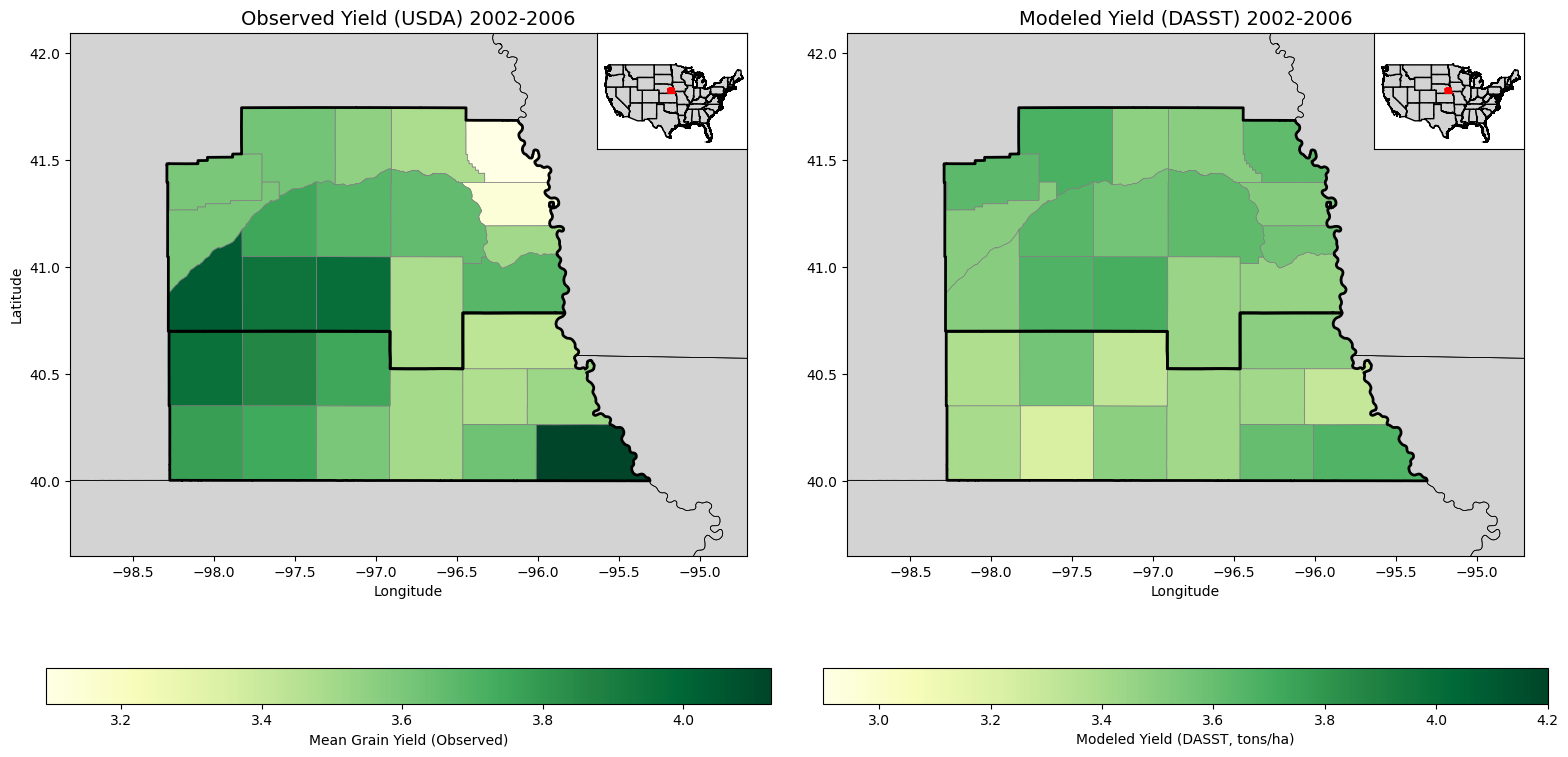

✓ DASST maps generated


In [10]:
# ---------------------------------------------------------------------------
# DASST (CSM-CROPGRO): plot observed vs modeled
# ---------------------------------------------------------------------------
plot_yield_map(
    grain_mean_BioCro_districts,
    model_col='DASST_soyben Crop yield',
    model_label='DASST',
)
print("\u2713 DASST maps generated")

C:\Users\yaron\AppData\Local\Temp\ipykernel_1536\4110487631.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


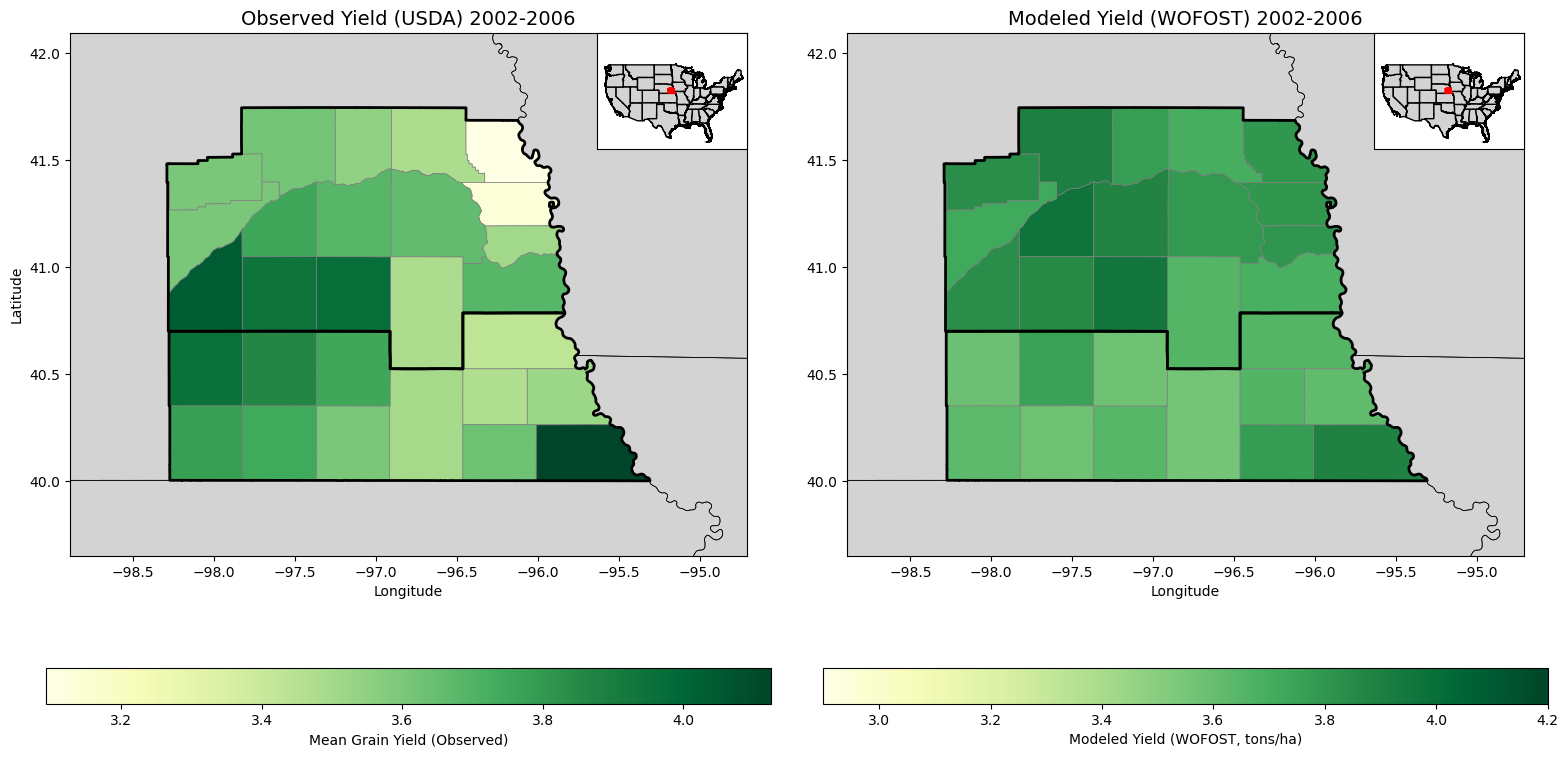

✓ WOFOST maps generated


In [11]:
# ---------------------------------------------------------------------------
# WOFOST: plot observed vs modeled
# ---------------------------------------------------------------------------
plot_yield_map(
    grain_mean_BioCro_districts,
    model_col='wofrst Crop yield',
    model_label='WOFOST',
)
print("\u2713 WOFOST maps generated")

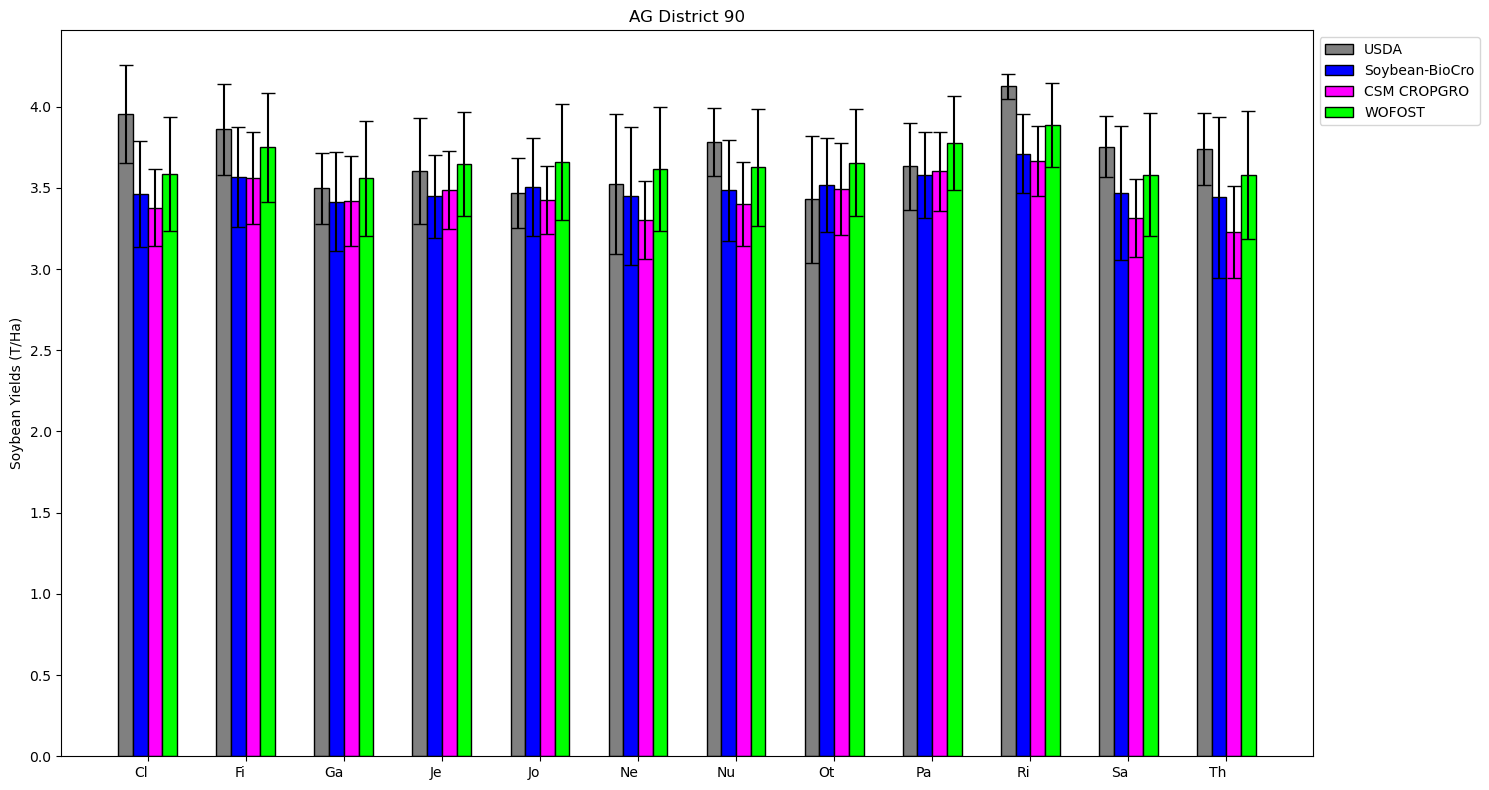

In [12]:
# ---------------------------------------------------------------------------
# Bar chart — AG District 90
# ---------------------------------------------------------------------------
df_d90 = plot_bar_chart(
    USDA_DISTRICT_90_CSV, BIOCRO_D90_CSV, CSM_D90_CSV, WOFOST_D90_CSV,
    district_label='District 90'
)

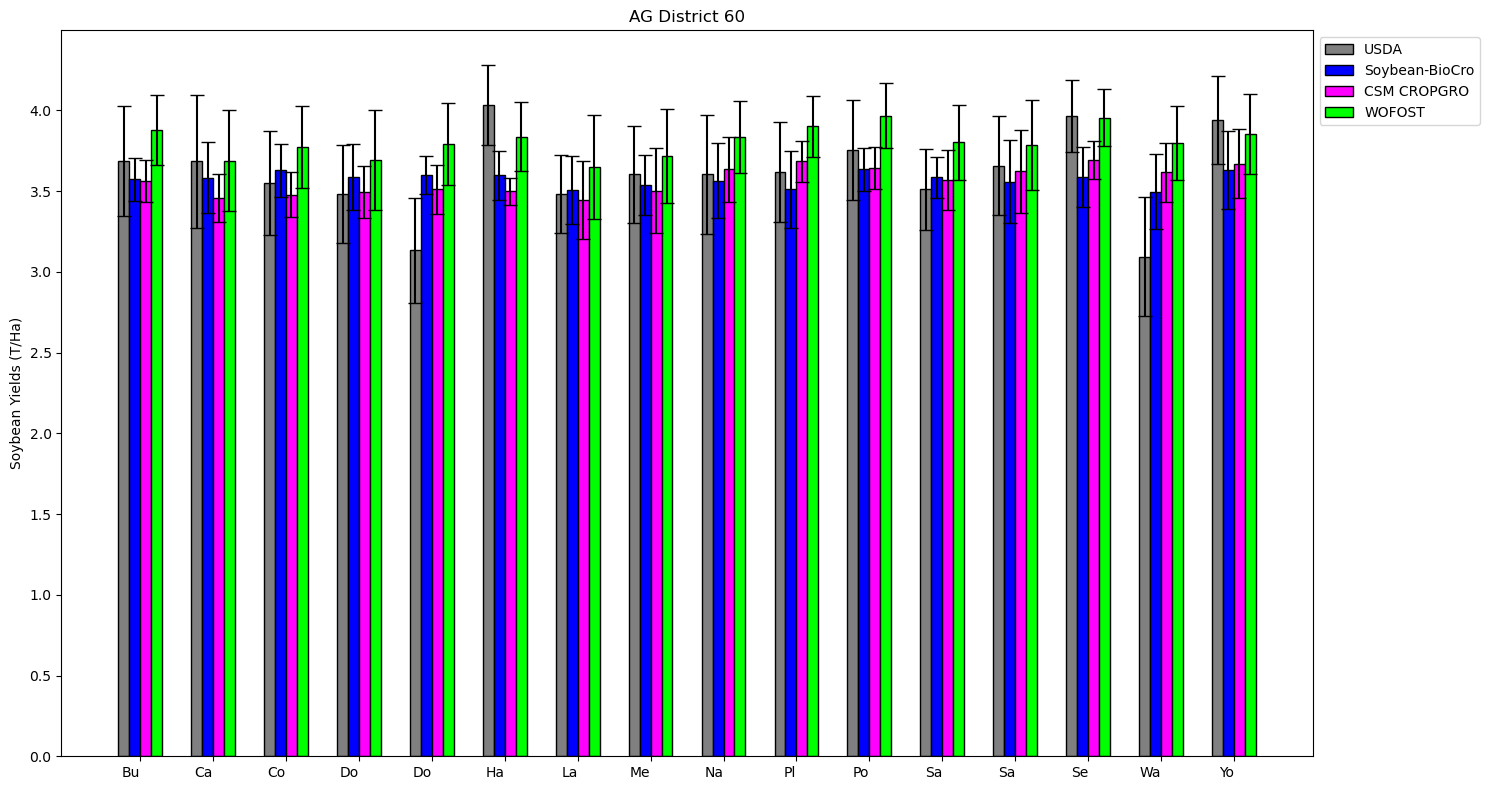

In [13]:
# ---------------------------------------------------------------------------
# Bar chart — AG District 60
# ---------------------------------------------------------------------------
df_d60 = plot_bar_chart(
    USDA_DISTRICT_60_CSV, BIOCRO_D60_CSV, CSM_D60_CSV, WOFOST_D60_CSV,
    district_label='District 60'
)